In [1]:
%pip install xgboost


[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: /usr/local/opt/python@3.11/bin/python3.11 -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import os

# --- Configuration ---
# Define local paths and GitHub URLs
local_train = "data/train_data.csv"
local_test = "data/test_data.csv"
github_train = "https://raw.githubusercontent.com/nurin1732/Blood-Prediction-Project/refs/heads/main/model/data/train_data.csv"
github_test = "https://raw.githubusercontent.com/nurin1732/Blood-Prediction-Project/refs/heads/main/model/data/test_data.csv"

# Check for training data
if os.path.exists(local_train):
    print("Loading train data from local disk...")
    train = pd.read_csv(local_train)
else:
    print("Local train data not found. Fetching from GitHub and saving locally...")
    train = pd.read_csv(github_train)
    train.to_csv("data/train_data.csv", index=False)

# Check for testing data
if os.path.exists(local_test):
    print("Loading test data from local disk...")
    test = pd.read_csv(local_test)
else:
    print("Local test data not found. Fetching from GitHuband saving locally...")
    test = pd.read_csv(github_test)
    test.to_csv("data/test_data.csv", index=False)

print("Train Shape:", train.shape)
print("Test Shape:", test.shape)

Loading train data from local disk...
Loading test data from local disk...
Train Shape: (9503, 17)
Test Shape: (4745, 17)


In [3]:
print(train.columns)

Index(['date', 'state', 'daily', 'blood_a', 'blood_b', 'blood_ab', 'blood_o',
       'donations_new', 'donations_regular', 'donations_irregular',
       'spike_flag', 'is_holiday', 'is_weekend', 'days_to_holiday',
       'regular_ratio', '7dayave_regular', '30dayave_new'],
      dtype='object')


In [4]:
features = [
    'is_holiday',
    'is_weekend',
    'days_to_holiday',
    'regular_ratio',
    '7dayave_regular',
    '30dayave_new'
]

X_train = train[features]
y_train = train['daily']

X_test = test[features]
y_test = test['daily']

print(X_train.shape)
print(X_test.shape)

(9503, 6)
(4745, 6)


In [5]:
from xgboost import XGBRegressor

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

print("Training Complete")

Training Complete


In [6]:
pred = model.predict(X_test)

print(pred[:10])

[ 77.76804   65.16835   87.388664 183.39612  173.20747  109.517975
  90.08352  111.78639  102.79395   89.13431 ]


In [7]:
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score
import numpy as np

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("MAE =", round(mae,2))
print("RMSE =", round(rmse,2))
print("R2 =", round(r2,4))

MAE = 40.94
RMSE = 68.58
R2 = 0.8117


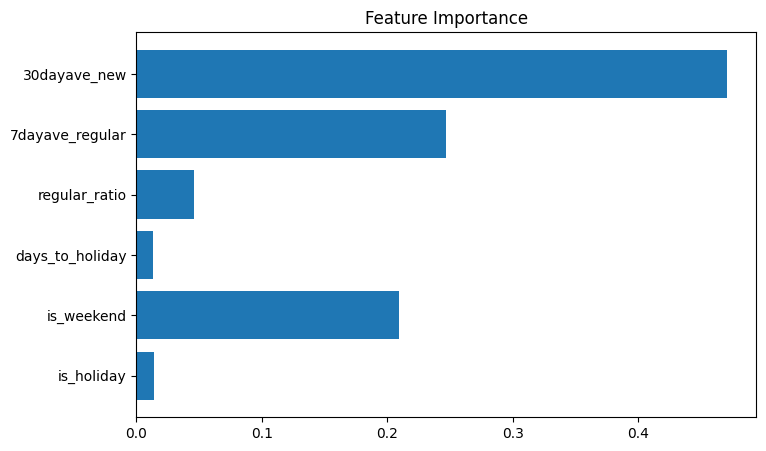

In [8]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

plt.figure(figsize=(8,5))
plt.barh(features, importance)
plt.title("Feature Importance")
plt.show()

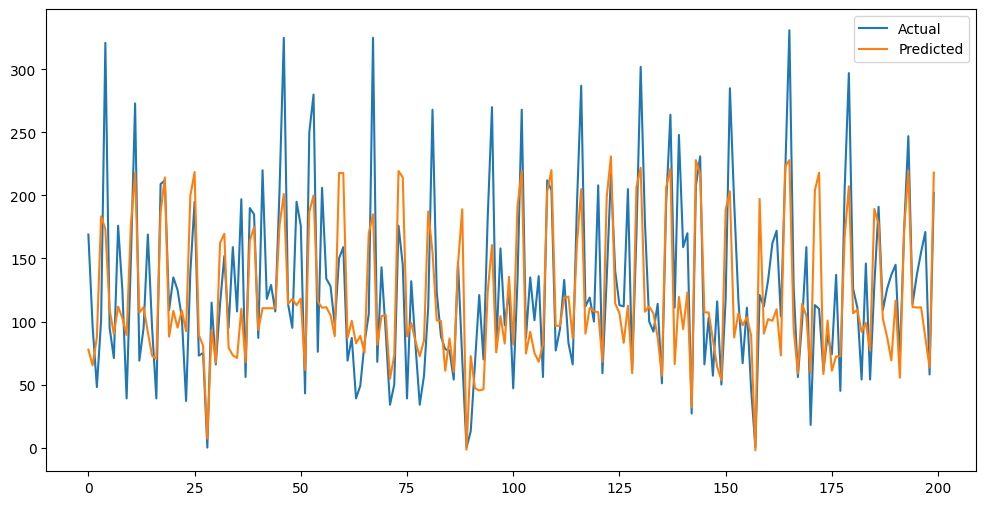

In [9]:
plt.figure(figsize=(12,6))

plt.plot(y_test.values[:200], label='Actual')
plt.plot(pred[:200], label='Predicted')

plt.legend()
plt.show()

In [10]:
import pandas as pd

train = pd.read_csv("data/train_data.csv")
test = pd.read_csv("data/test_data.csv")

print(train.shape)
print(test.shape)

(9503, 17)
(4745, 17)


In [11]:
from xgboost import XGBRegressor

features = [
    'is_holiday',
    'is_weekend',
    'days_to_holiday',
    'regular_ratio',
    '7dayave_regular',
    '30dayave_new'
]

X_train = train[features]
y_train = train['daily']

X_test = test[features]
y_test = test['daily']

model = XGBRegressor(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Model Ready")

Model Ready


In [12]:
dashboard_df = test.copy()

dashboard_df["predicted_daily"] = pred

dashboard_df.head()

,date,state,daily,blood_a,blood_b,blood_ab,blood_o,donations_new,donations_regular,donations_irregular,spike_flag,is_holiday,is_weekend,days_to_holiday,regular_ratio,7dayave_regular,30dayave_new,predicted_daily
0,2025-01-01,Johor,169,49,45,6,69,19,122,28,none,0,0,28.0,0.72,90.14,28.57,77.768044
1,2025-01-02,Johor,96,19,20,4,53,3,75,18,none,0,0,27.0,0.77,91.00,28.67,65.168350
2,2025-01-03,Johor,48,13,9,4,22,6,34,8,none,0,0,26.0,0.69,93.71,27.30,87.388664
3,2025-01-04,Johor,101,27,21,6,47,25,59,17,none,0,1,25.0,0.58,95.43,26.80,183.396118
4,2025-01-05,Johor,321,79,78,24,140,79,184,58,normal_spike,0,1,24.0,0.57,89.00,25.33,173.207474


In [13]:
dashboard_df.to_csv(
    "data/final_dashboard_data.csv",
    index=False
)

print("CSV Saved")

CSV Saved
